# Analýza a vizualizace dat

## Pandas

### Series

In [6]:
import pandas as pd

s = pd.Series(range(5), index=["a", "b", "c", "d", "e"])
s

a    0
b    1
c    2
d    3
e    4
dtype: int64

#### alignment

In [3]:
s1 = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
s2 = pd.Series([4, 5, 6], index=['b', 'c', 'd'])

In [4]:
# alignment by index, missing values set o NaN
s1 + s2

a    NaN
b    6.0
c    8.0
d    NaN
dtype: float64

In [5]:
s1.values + s2.values  # contrast

array([5, 7, 9])

#### Indexing

In [8]:
s = pd.Series(range(5), index=["a", "b", "c", "d", "e"])
s["b":], s.iloc[2:]

(b    1
 c    2
 d    3
 e    4
 dtype: int64,
 c    2
 d    3
 e    4
 dtype: int64)

### Dataframe

In [12]:
d = {
    "one": [1., 2., 3., 4.],
    "two": [4, 3, 2, 1],
    "three": ["eins", "zwei", "drei", "vier"]
}
df = pd.DataFrame(d, index=["a", "b", "c", "d"])
df

,one,two,three
a,1.0,4,eins
b,2.0,3,zwei
c,3.0,2,drei
d,4.0,1,vier


#### Indexování v Dataframe

In [14]:
# vychozi indexovani dle sloupce, vraci series
df["one"]

a    1.0
b    2.0
c    3.0
d    4.0
Name: one, dtype: float64

In [15]:
# vice sloupcu nutno predat jako iterable
# (DataFrame.__getitem__ prijima jeden argument)
df[["one", "two"]]

,one,two
a,1.0,4
b,2.0,3
c,3.0,2
d,4.0,1


In [16]:
# pro vyber dle indexu nutno pouzit .loc
df.loc["a"]

one       1.0
two         4
three    eins
Name: a, dtype: object

In [18]:
# pripadne .iloc pro vyber dle poradi
df.iloc[2:]

,one,two,three
c,3.0,2,drei
d,4.0,1,vier


In [20]:
# vyber je casto spojen s maskovanim
df[df["two"] > 2]

,one,two,three
a,1.0,4,eins
b,2.0,3,zwei


#### Explore

In [ ]:
df.tail()

In [ ]:
df.describe()

### Ukázkový datasety a pokročilé operace

In [22]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

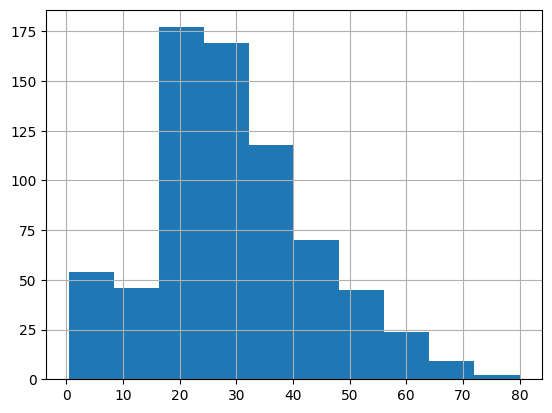

In [25]:
df["Age"].hist()
df.groupby("Sex")["Survived"].mean()

In [24]:
mask = df["Survived"] == 0
filtered = df[mask]
filtered.groupby("Sex").agg({"Age": ["mean", "median"]})

Age       
             mean median
Sex                     
female  25.046875   24.5
male    31.618056   29.0

## Matplotlib

### Základy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 20)
y = np.sin(x)

plt.plot(x, y, 'x--r', label="sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sinus")
plt.xlim(0, np.pi)
plt.legend()
plt.show()

### figure and axes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

x = np.linspace(0, np.pi, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

ax1.plot(x, y_sin)
ax2.plot(x, y_cos)

ax1.set_xlabel("neco")
ax2.set_title("cos(x)")

plt.tight_layout()

fig.savefig("graf.jpg", dpi=300) 

### Colormaps

In [ ]:
import numpy  as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

cmap = plt.get_cmap("viridis")
N = 10
colors = cmap(np.linspace(0, 1, N))

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for i in range(1, N+1):
    ax.plot(x, y * i, label=f"{i}", color=colors[i-1])

ax.legend()
print(colors)
plt.show()

### Barplot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

strany = ["KSČM", "ANO", "TOP09", "Piráti", "ČSSD", "Zelení"]
barvy = ["red", "blue", "purple", "black", "orange", "green"]

np.random.seed(19680801)
hlasy = np.random.randint(0,150, len(strany))

plt.figure(figsize=(8,6))
plt.bar(strany, hlasy, color = barvy)
plt.title("Parlamentní volby 2021")
plt.ylabel("hlasy (tis.)")
plt.show()

### 4D data ve 2D obrázku

In [ ]:
import numpy as np

def generate_data(n=50, seed=123456):
    # study hours (not perfectly uniform)
    hours = np.linspace(0, 10, n) + np.random.normal(0, 0.5, n)
    hours = np.clip(hours, 0, None)
    
    # course difficulty (structured, not random chaos)
    difficulty = np.random.choice([10, 20, 30, 40], size=n)
    
    # stress: increases with hours AND difficulty
    stress_level = (
        5 * hours
        + 1.5 * difficulty
        + np.random.normal(0, 10, n)
    )
    stress_level = np.clip(stress_level, 5, None)
    
    # exam score:
    # - increases with study
    # - decreases with difficulty
    # - penalized by too much stress
    # - slight diminishing returns on study
    exam_score = (
        40
        + 6 * hours
        - 0.5 * difficulty
        - 0.05 * stress_level
        - 0.3 * hours**2   # diminishing returns
        + np.random.normal(0, 5, n)
    )
    
    exam_score = np.clip(exam_score, 0, 100)
    data = {
        "hours": hours,
        "exam_score": exam_score,
        "difficulty": difficulty,
        "stress_level": stress_level
    }
    return data

In [ ]:
import matplotlib.pyplot as plt

data = generate_data()

plt.scatter(
    'hours',
    'exam_score',
    c='difficulty',
    s='stress_level',
    data=data,
    alpha=1.0,
    cmap='viridis'
)

plt.xlabel('Study hours per week')
plt.ylabel('Exam score')
plt.colorbar(label='Difficulty')
plt.show()

## "Projekt"

In [1]:
import numpy as np
import pandas as pd

def generate_grades(n=200, seed=42):
    np.random.seed(seed)

    names = [f"Student_{i}" for i in range(n)]
    
    classes = np.random.choice(["A", "B", "C"], size=n, p=[0.3, 0.4, 0.3])

    study_hours = np.random.normal(4, 1.5, n)
    study_hours = np.clip(study_hours, 0, 10)

    attendance = np.random.uniform(0.6, 1.0, n)

    score = (
        30
        + 8 * study_hours
        + 20 * attendance
        + np.random.normal(0, 8, n)
    )

    score = np.clip(score, 0, 100)

    df = pd.DataFrame({
        "name": names,
        "class": classes,
        "study_hours": study_hours,
        "attendance": attendance,
        "score": score
    })

    return df

generate_grades().to_csv("students.csv")

           score               passed
            mean        std      mean
class                                
A      78.171485  13.646975  0.969697
B      77.040864  14.036308  0.986486
C      78.399662  12.087713  1.000000


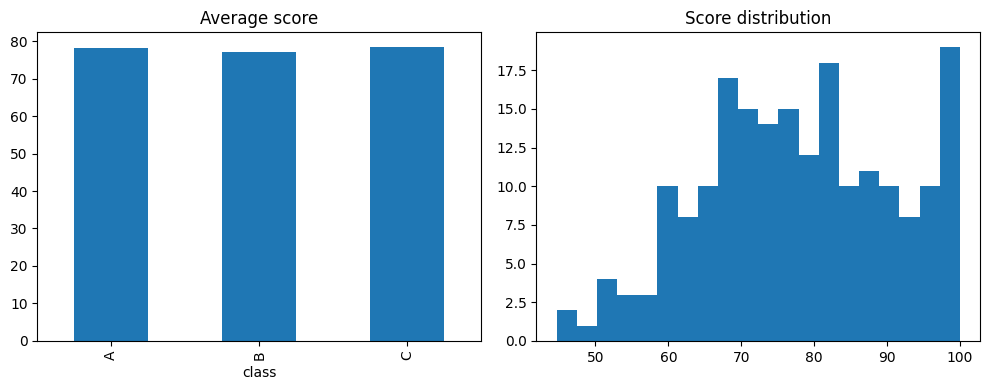

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load
df = pd.read_csv("students.csv")

# clean
df = df.dropna()
df["passed"] = df["score"] > 50


# grouping
summary = df.groupby("class").agg({
    "score": ["mean", "std"],
    "passed": "mean"
})

print(summary)

# plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# mean score per class
df.groupby("class")["score"].mean().plot(kind="bar", ax=axs[0])
axs[0].set_title("Average score")

# distribution
axs[1].hist(df["score"], bins=20)
axs[1].set_title("Score distribution")

plt.tight_layout()